# Residual mass vs $N_5$
$\beta=3$, $m=0.05$, $32\times64$ (the `scan_N5_m0.05.sh` ensembles). $R(t)=\langle J_{5q}(t)P(0)\rangle/\langle P(t)P(0)\rangle\to m_{res}$; caches come from `buildDistill_mres.py` (800 groups each).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import schwingerModel as sim
from schwingerModel import plotting as sp
from schwingerModel.mRes import bootstrapMres, plateauReduce

sp.setStyle()

beta, m0, Nx, Nt = 3.0, 0.05, 32, 64
N5s = [2, 4, 8, 12, 16, 20, 24, 32]
nGroups = 800     # a cache still being written has fewer groups: skip it for now

# fixed color/marker per N5 across every figure in this notebook
n5Style = {N5: (sp.PALETTE[i], sp.MARKERS[i]) for i, N5 in enumerate(N5s)}
runTitle = rf"$\beta={beta}$, $m_0={m0}$, $N_x={Nx}$, $N_t={Nt}$"
stem = f"beta{beta}_m{m0}_Nx{Nx}_Nt{Nt}"

def yerr(err):
    #bootstrap rows are [high-central, central-low]; matplotlib wants [lower, upper]
    return np.clip(err, 0.0, None)[::-1]

In [2]:
# only finished caches that carry the mres datasets (N5=16 predates them)
data = {}
for N5 in N5s:
    path = f"configs/dwf_beta_{beta}_m_{m0}_Nx_{Nx}_Nt_{Nt}_N5_{N5}.hdf5"
    if not os.path.exists(path):
        continue
    try:
        C_PP, C_JP = sim.distillation.readMres(path)
    except KeyError as e:               # cache predates the mres datasets
        print(e); continue
    except BlockingIOError:             # hdf5 lock: generateDistillFile is writing it
        print(f"N5={N5}: cache locked by the generator -- skipped"); continue
    if len(C_PP) < nGroups:
        print(f"N5={N5}: {len(C_PP)}/{nGroups} groups, still generating -- skipped"); continue
    data[N5] = (C_PP, C_JP)
print("loaded N5 =", sorted(data))

loaded N5 = [2, 4, 8, 12, 16, 20, 24, 32]


## Ratio curves

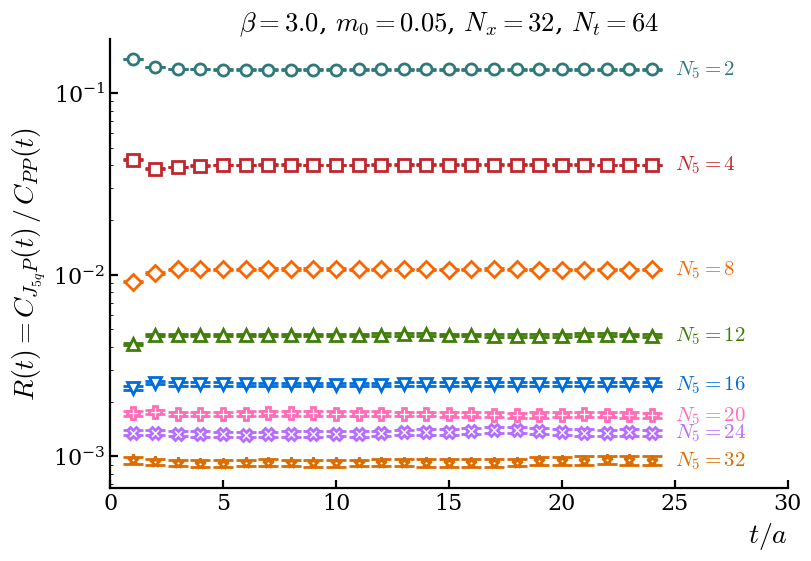

In [3]:
curves = {N5: bootstrapMres(*data[N5], numResamples=2000, seed=0, progress=False)
          for N5 in data}

tMax = 24
ts = np.arange(1, tMax + 1)              # dt=0 is the contact term
fig, ax = plt.subplots(figsize=(8, 5.5), layout="constrained")
for N5, (R, err, _) in curves.items():
    col, mk = n5Style[N5]
    ax.errorbar(ts, R[ts], yerr=yerr(err[:, ts]), marker=mk, color=col, mec=col, **sp.eb_kw)
    ax.text(tMax + 1, R[tMax], rf"$N_5={N5}$", color=col, ha="left", va="center",
            fontsize=15, zorder=5, bbox=sp.TEXTBOX)
ax.set_yscale("log")
ax.set_xlim(0, tMax + 6)
ax.set_xlabel(r"$t/a$", loc="right")
ax.set_ylabel(r"$R(t) = C_{J_{5q}P}(t)\,/\,C_{PP}(t)$")
ax.set_title(runTitle)
fig.savefig(f"figs/mresRatio_{stem}.pdf")
plt.show()

## Plateau vs $t_{min}$
One bootstrap per $N_5$ over the whole list of windows $[t_{min}, t_{max})$, so the points of a series share resamples (window-to-window covariance is in `cov`).

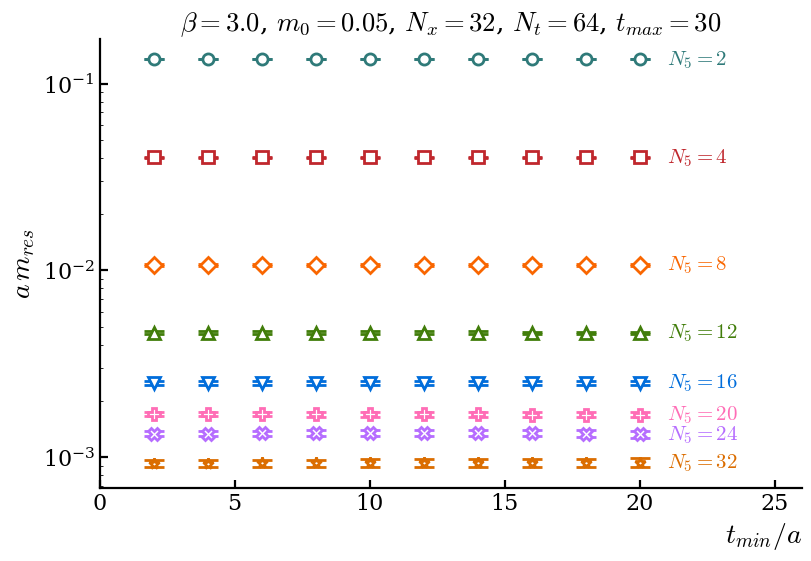

N5= 2: m_res = 0.13500(25)  (t_min=8, t_max=30)
N5= 4: m_res = 0.04033(15)  (t_min=8, t_max=30)
N5= 8: m_res = 0.010703(95)  (t_min=8, t_max=30)
N5=12: m_res = 0.004640(72)  (t_min=8, t_max=30)
N5=16: m_res = 0.002496(62)  (t_min=8, t_max=30)
N5=20: m_res = 0.001698(52)  (t_min=8, t_max=30)
N5=24: m_res = 0.001341(49)  (t_min=8, t_max=30)
N5=32: m_res = 0.000925(44)  (t_min=8, t_max=30)


In [4]:
tMins = np.arange(2, 22, 2)
tMax = 30
windows = [(lo, tMax) for lo in tMins]

plateau = {N5: bootstrapMres(*data[N5], reduce=plateauReduce(windows),
                             numResamples=2000, seed=0, progress=False)
           for N5 in data}

fig, ax = plt.subplots(figsize=(8, 5.5), layout="constrained")
for N5, (mres, err, _) in plateau.items():
    col, mk = n5Style[N5]
    ax.errorbar(tMins, mres, yerr=yerr(err), marker=mk, color=col, mec=col, **sp.eb_kw)
    ax.text(tMins[-1] + 1, mres[-1], rf"$N_5={N5}$", color=col, ha="left", va="center",
            fontsize=15, zorder=5, bbox=sp.TEXTBOX)
ax.set_yscale("log")
ax.set_xlim(0, tMins[-1] + 6)
ax.set_xlabel(r"$t_{min}/a$", loc="right")
ax.set_ylabel(r"$a\,m_{res}$")
ax.set_title(runTitle + rf", $t_{{max}}={tMax}$")
fig.savefig(f"figs/mresPlateau_{stem}.pdf")
plt.show()

i = list(tMins).index(8)
for N5, (mres, err, _) in plateau.items():
    print(f"N5={N5:2d}: m_res = {sp.fmtErr(mres[i], err[:, i].max())}  (t_min=8, t_max={tMax})")

## $m_{res}$ vs $N_5$
Plateau value at $t_{min}=8$; the grey line is the input mass $m_0$.

Fit to the Golterman–Shamir / RBC form
$$m_{res}(N_5) = \frac{R_e\,e^{-\lambda_c N_5} + R_0}{N_5},$$
extended modes of $H_W$ above the mobility edge $\lambda_c$ give the exponential; localized near-zero modes (density $\propto R_0$) give the $1/N_5$ tail that survives at any $N_5$. The form is asymptotic, so $N_5=2$ ($m_{res}\gg m_0$) is excluded (`fitMin`); the grey $R_0/N_5$ line is the tail alone.

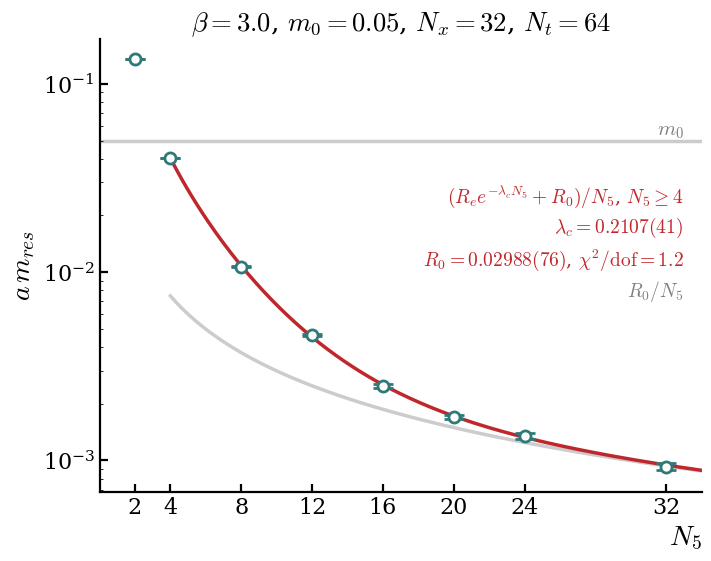

R_e = 0.3051(45), lambda_c = 0.2107(41), R_0 = 0.02988(76), chi2/dof = 1.16


In [5]:
from scipy.optimize import curve_fit

n5 = np.array(sorted(plateau))
mres = np.array([plateau[N5][0][i] for N5 in n5])
err = np.array([plateau[N5][1][:, i] for N5 in n5]).T      # (2, nN5)

def mresForm(N5, Re, lamC, R0):
    return (Re * np.exp(-lamC * N5) + R0) / N5

fitMin = 4
sel = n5 >= fitMin
sig = err[:, sel].max(axis=0)                           # symmetrized bootstrap error
pFit, pCov = curve_fit(mresForm, n5[sel], mres[sel], p0=(0.3, 0.3, 0.03),
                       sigma=sig, absolute_sigma=True)
pErr = np.sqrt(np.diag(pCov))
chi2dof = np.sum(((mres[sel] - mresForm(n5[sel], *pFit)) / sig) ** 2) / (sel.sum() - 3)
Re, lamC, R0 = pFit

fig, ax = plt.subplots(figsize=(7, 5.5), layout="constrained")
ax.axhline(m0, color=sp.GREY, lw=sp.LW, zorder=0)
ax.text(0.97, m0, r"$m_0$", color="0.5", ha="right", va="bottom", fontsize=15,
        transform=ax.get_yaxis_transform(), zorder=5)
nn = np.linspace(fitMin, N5s[-1] + 2, 200)
ax.plot(nn, R0 / nn, color=sp.GREY, lw=sp.LW, zorder=0)
ax.plot(nn, mresForm(nn, *pFit), color=sp.JLab_red, lw=sp.LW, zorder=2)
ax.errorbar(n5, mres, yerr=yerr(err), marker="o", color=sp.JLab_blue, mec=sp.JLab_blue, **sp.eb_kw)

legendLines = [(rf"$(R_e e^{{-\lambda_c N_5}} + R_0)/N_5$, $N_5\geq{fitMin}$", sp.JLab_red),
               (rf"$\lambda_c = {sp.fmtErr(lamC, pErr[1])}$", sp.JLab_red),
               (rf"$R_0 = {sp.fmtErr(R0, pErr[2])}$, $\chi^2/\mathrm{{dof}} = {chi2dof:.1f}$", sp.JLab_red),
               (r"$R_0/N_5$", "0.5")]
for j, (txt, col) in enumerate(legendLines):
    ax.text(0.97, 0.68 - 0.07 * j, txt, color=col, ha="right", va="top",
            transform=ax.transAxes, fontsize=14, zorder=5, bbox=sp.TEXTBOX)

ax.set_yscale("log")
ax.set_xlim(0, N5s[-1] + 2)
ax.set_xticks(N5s)
ax.set_xlabel(r"$N_5$", loc="right")
ax.set_ylabel(r"$a\,m_{res}$")
ax.set_title(runTitle)
fig.savefig(f"figs/mresVsN5_{stem}.pdf")
plt.show()

print(f"R_e = {sp.fmtErr(Re, pErr[0])}, lambda_c = {sp.fmtErr(lamC, pErr[1])}, "
      f"R_0 = {sp.fmtErr(R0, pErr[2])}, chi2/dof = {chi2dof:.2f}")
for N5 in N5s:
    if N5 not in plateau:
        print(f"  predicted m_res(N5={N5}) = {mresForm(N5, *pFit):.5f}")

## $m_{res}$ vs $M_5$
`scan_M5_m0.05.sh`: $\beta=3$, $m_0=0.05$, $N_x=32$ at $N_5=8$ and $16$ for $M_5\in\{0.5, 0.75, 1.25, 1.5, 1.75\}$ (1.0 is the main scan). In free field the domain-wall mode decays as $(1-M_5)^s$, so binding is perfect at $M_5=1$; gauge fluctuations shift the effective $M_5$ down, moving the optimum above 1 (QCD uses ~1.8). Both $N_5$ are shown; the $N_5=16$ curve is the one that bounds the $1/N_5$ tail, $R_0 \le 16\,m_{res}(16)$.

available: {8: [0.5, 0.75, 1.0, 1.125, 1.25, 1.375, 1.5, 1.75], 16: [0.5, 0.75, 1.0, 1.125, 1.25, 1.375, 1.5, 1.75], 24: [1.0, 1.125, 1.25, 1.375, 1.5, 1.625]}


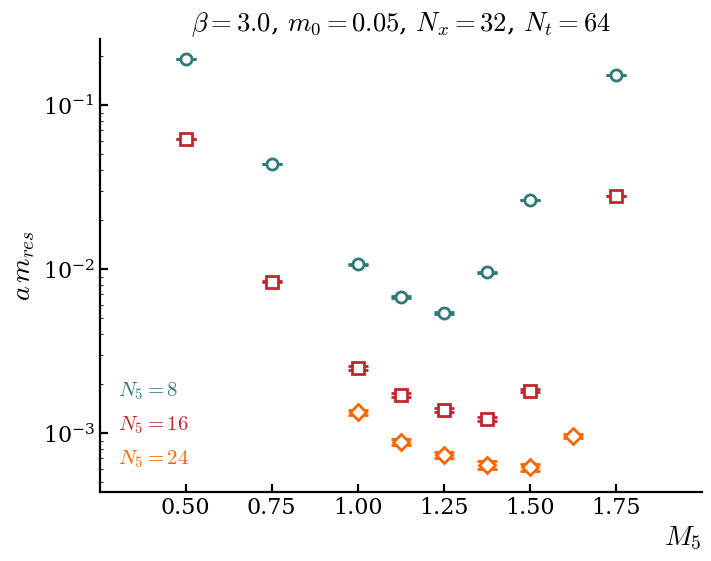

M5     N5=8           N5=16          N5=24          16*m_res(16) >= R_0
0.5    0.19021(33)    0.06210(34)    --             0.9936
0.75   0.04380(16)    0.00839(12)    --             0.1342
1.0    0.010703(95)   0.002496(62)   0.001341(49)   0.0399
1.125  0.006772(74)   0.001706(47)   0.000886(37)   0.0273
1.25   0.005399(58)   0.001376(43)   0.000735(32)   0.0220
1.375  0.009539(53)   0.001214(39)   0.000636(38)   0.0194
1.5    0.026370(56)   0.001816(40)   0.000618(31)   0.0291
1.625  --             --             0.000961(26)   
1.75   0.15309(20)    0.027849(74)   --             0.4456


In [6]:
M5s = [0.5, 0.75, 1.0, 1.125, 1.25, 1.375, 1.5, 1.625, 1.75]
m5N5s = [8, 16, 24]
m5Style = {8: (sp.JLab_blue, "o"), 16: (sp.JLab_red, "s"), 24: (sp.JLab_orange, "D")}

def m5Path(M5, N5):
    suffix = "" if M5 == 1.0 else f"_M5_{M5}"
    return f"configs/dwf_beta_{beta}_m_{m0}_Nx_{Nx}_Nt_{Nt}_N5_{N5}{suffix}.hdf5"

def loadMres(path):
    """(C_PP, C_JP) of a finished cache, or None (missing / still being written)."""
    if not os.path.exists(path):
        return None
    try:
        C_PP, C_JP = sim.distillation.readMres(path)
    except (KeyError, BlockingIOError):        # pre-mres cache, or locked by the generator
        return None
    return (C_PP, C_JP) if len(C_PP) >= nGroups else None

m5Res = {}                                  # (M5, N5) -> [central, err, cov] at fitT
for N5 in m5N5s:
    for M5 in M5s:
        data = loadMres(m5Path(M5, N5))
        if data is None:
            continue
        m5Res[(M5, N5)] = bootstrapMres(*data, reduce=plateauReduce((8, tMax)),
                                        numResamples=2000, seed=0, progress=False)
print("available:", {N5: [M5 for M5 in M5s if (M5, N5) in m5Res] for N5 in m5N5s})

fig, ax = plt.subplots(figsize=(7, 5.5), layout="constrained")
for N5 in m5N5s:
    pts = [(M5, *m5Res[(M5, N5)][:2]) for M5 in M5s if (M5, N5) in m5Res]
    x = np.array([p[0] for p in pts]); y = np.array([p[1] for p in pts])
    e = np.array([p[2] for p in pts]).T
    col, mk = m5Style[N5]
    ax.errorbar(x, y, yerr=yerr(e), marker=mk, color=col, mec=col, **sp.eb_kw)
    ax.text(0.03, 0.05 + 0.075 * (len(m5N5s) - 1 - m5N5s.index(N5)), rf"$N_5={N5}$",
            color=col, ha="left", va="bottom", transform=ax.transAxes, fontsize=15,
            zorder=5, bbox=sp.TEXTBOX)
ax.set_yscale("log")
ax.set_xlim(0.25, 2.0)
ax.set_xticks([0.5, 0.75, 1.0, 1.25, 1.5, 1.75])
ax.set_xlabel(r"$M_5$", loc="right")
ax.set_ylabel(r"$a\,m_{res}$")
ax.set_title(runTitle)
fig.savefig(f"figs/mresVsM5_{stem}.pdf")
plt.show()

f = lambda r: sp.fmtErr(r[0], r[1].max()) if r else "--"
print("M5     " + "".join(f"N5={N5:<12}" for N5 in m5N5s) + "16*m_res(16) >= R_0")
for M5 in M5s:
    row = [m5Res.get((M5, N5)) for N5 in m5N5s]
    if not any(row):
        continue
    r16 = m5Res.get((M5, 16))
    print(f"{M5:<5}  " + "".join(f"{f(r):<15}" for r in row) + (f"{16 * r16[0]:.4f}" if r16 else ""))

### $\lambda_c$ and $R_0$ vs $M_5$
For every $M_5$ with at least three $N_5$ points, fit $(R_e e^{-\lambda_c N_5}+R_0)/N_5$ (three points make it an exact solve; the errors are the propagated point errors). $M_5=1$ uses the full $N_5$ scan. Fills in as the $N_5=24$ caches arrive.

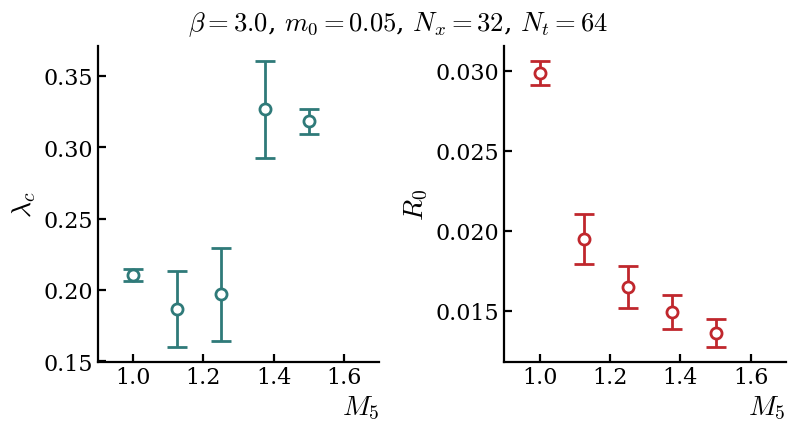

M5=1.0   (7 N5 points): R_e=0.3051(45)  lambda_c=0.2107(41)  R_0=0.02988(76)
M5=1.125 (3 N5 points): R_e=0.154(27)  lambda_c=0.187(27)  R_0=0.0195(16)
M5=1.25  (3 N5 points): R_e=0.129(29)  lambda_c=0.197(33)  R_0=0.0165(13)
M5=1.375 (3 N5 points): R_e=0.84(22)  lambda_c=0.327(34)  R_0=0.0149(11)
M5=1.5   (3 N5 points): R_e=2.52(17)  lambda_c=0.3185(88)  R_0=0.01362(87)


In [7]:
m5Fits = {}
for M5 in M5s:
    pts = [(N5, *m5Res[(M5, N5)][:2]) for N5 in m5N5s if (M5, N5) in m5Res]
    if M5 == 1.0:                                   # the main scan has every N5
        pts = [(N5, plateau[N5][0][i], plateau[N5][1][:, i]) for N5 in sorted(plateau) if N5 >= fitMin]
    if len(pts) < 3:
        continue
    x = np.array([p[0] for p in pts], float); y = np.array([p[1] for p in pts])
    s = np.array([np.max(p[2]) for p in pts])
    try:
        p, cov = curve_fit(mresForm, x, y, p0=(0.3, 0.2, 0.03), sigma=s, absolute_sigma=True, maxfev=20000)
    except RuntimeError as e:
        print(f"M5={M5}: fit failed ({e})"); continue
    m5Fits[M5] = (p, np.sqrt(np.diag(cov)), len(pts))

if m5Fits:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4.2), layout="constrained")
    fig.get_layout_engine().set(w_pad=0.12)
    for ax, k, lab, col in zip(axes, (1, 2), (r"$\lambda_c$", r"$R_0$"), (sp.JLab_blue, sp.JLab_red)):
        xs = np.array(sorted(m5Fits)); ys = np.array([m5Fits[M5][0][k] for M5 in xs])
        es = np.array([m5Fits[M5][1][k] for M5 in xs])
        ax.errorbar(xs, ys, yerr=es, marker="o", color=col, mec=col, **sp.eb_kw)
        ax.set_xlabel(r"$M_5$", loc="right"); ax.set_ylabel(lab)
        ax.set_xlim(0.9, 1.7)
    fig.suptitle(runTitle)
    fig.savefig(f"figs/mresFitParamsVsM5_{stem}.pdf")
    plt.show()
    for M5, (p, e, n) in m5Fits.items():
        print(f"M5={M5:<5} ({n} N5 points): R_e={sp.fmtErr(p[0], e[0])}  lambda_c={sp.fmtErr(p[1], e[1])}  R_0={sp.fmtErr(p[2], e[2])}")
else:
    print("no M5 with >= 3 N5 points yet")